<a href="https://colab.research.google.com/github/rkuo2000/AI-exercise/blob/main/colab/YOLO26_Tanks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLO26 Tanks Train & Detect

## Dataset: [Tank by S.Danish](https://www.kaggle.com/datasets/rkuo2000/tank-by-s-danish)

## Download Dataset

In [1]:
import kagglehub
dataset_path = kagglehub.dataset_download('rkuo2000/tank-by-s-danish')
print(dataset_path)

import os
print(os.listdir(dataset_path))

100%|██████████| 11.7M/11.7M [00:00<00:00, 57.1MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/rkuo2000/tank-by-s-danish/versions/1
['README.roboflow.txt', 'test', 'valid', 'README.dataset.txt', 'train', 'data.yaml']


In [4]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 932.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 11.1 MB/s eta 0:00:00


## Download a pretrained model

In [5]:
from ultralytics import YOLO
model = YOLO("yolo26n.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [6]:
%%writefile tanks.yaml

train: /root/.cache/kagglehub/datasets/rkuo2000/tank-by-s-danish/versions/1/train/images
val:  /root/.cache/kagglehub/datasets/rkuo2000/tank-by-s-danish/versions/1/valid/images
test:  /root/.cache/kagglehub/datasets/rkuo2000/tank-by-s-danish/versions/1/test/images

nc: 3
names: ['tank', 'vehicle', 'wqw']

Writing tanks.yaml


## Train YOLO26

In [7]:
results = model.train(data="./tanks.yaml", epochs=100, imgsz=640)

Ultralytics 8.4.161 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./tanks.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optimizer=au

In [8]:
!ls /root/.cache/kagglehub/datasets/rkuo2000/tank-by-s-danish/versions/1/test/images

22_jpg.rf.b1ada215eee56580f3f0e7604b05b0fe.jpg
23_jpg.rf.0b3d28ae7ffc778689eddb1201f49cd0.jpg
25_jpg.rf.b5d73e8b6a33bb4d1cc93e5a52c28301.jpg
30_jpg.rf.9aef7a75a4163ea2b7b99bb6d022e58e.jpg
52_jpg.rf.1d79a5243bd15236d2d9a0e7a4e2a3dc.jpg
download-10-_jpg.rf.26f533bb5086fa50a832ba2c710efd27.jpg
download-18-_jpg.rf.4f80cec269cd2720985681da010ce507.jpg
gettyimages-1240137092-612x612_jpg.rf.d7e8e3e47771fcd33d86c6a5e5526647.jpg
gettyimages-1240949177-612x612_jpg.rf.f04c678723946866a3514fa459cb519c.jpg
gettyimages-1396282249-612x612_jpg.rf.06651e0ccb33ce880bb0bd4882d8cb1d.jpg
image_266_jpg.rf.96c15213acc73e6892ae51fc85d218ec.jpg
image_299_jpg.rf.786fd899a8e8f34c0b67da94b0071b81.jpg
image_303_jpg.rf.1a7aafdd5069bdcbb6aef0a6de5b7918.jpg
image_306_jpg.rf.a3f481384ddd920d36eb2bf355c0cdfd.jpg
image_309_jpg.rf.1ad2745f0b21165911828e4cf343231e.jpg
image_311_jpg.rf.8e3785d375449589f8bb091ff260e91f.jpg
image_427_jpg.rf.e830d93f2da87fbdffd141bc6f32eeb9.jpg
image_432_jpg.rf.0c978037006735a73678623785dc8b7

## Test trained-model


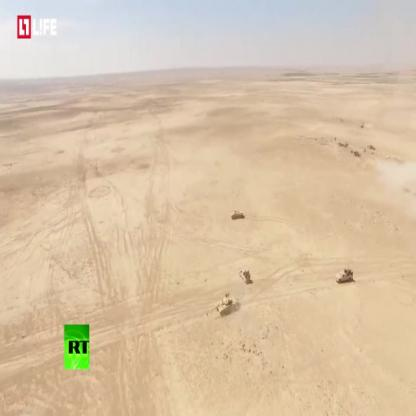

In [12]:
from IPython.display import Image, display
testfile = os.path.join(dataset_path, 'test', 'images', 'image_88_jpg.rf.1db53a7e14e975a31f4d01c2b9e4c5db.jpg')
display(Image(testfile))


image 1/1 /root/.cache/kagglehub/datasets/rkuo2000/tank-by-s-danish/versions/1/test/images/image_88_jpg.rf.1db53a7e14e975a31f4d01c2b9e4c5db.jpg: 640x640 (no detections), 8.6ms
Speed: 2.0ms preprocess, 8.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


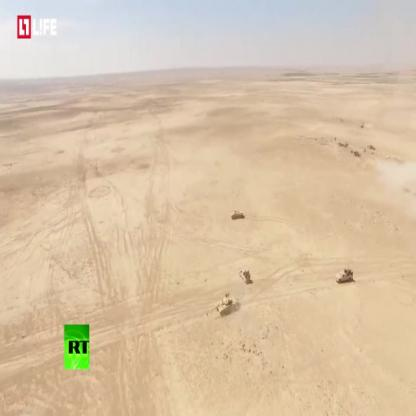

In [13]:
results = model(testfile)

results[0].show()